<a href="https://colab.research.google.com/github/SenTier1107/Appprogramming_2026/blob/main/customer_data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

uploaded = files.upload()

Saving customers.csv to customers.csv


In [6]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. 데이터 불러오기
df = pd.read_csv('customers.csv')

# 2. 불필요한 열 제거
# 고객ID와 같은 고유 식별자는 패턴 분석에 도움이 되지 않으므로 제외합니다.
df_processed = df.drop(columns=['고객ID'])

# 3. 순서가 있는 범주형 데이터 전처리 (Ordinal Encoding)
# 회원등급은 '브론즈 < 실버 < 골드'와 같이 순서가 중요하므로 직접 매핑합니다.
grade_mapping = {
    'Bronze': 1,
    'Silver': 2,
    'Gold': 3,
    'VIP': 4,
    'VVIP': 5
}
df_processed['회원등급'] = df_processed['회원등급'].map(grade_mapping)

# 4. 순서가 없는 범주형 데이터 전처리 (Label Encoding)
# 성별, 결제수단, 거주지는 Sklearn의 LabelEncoder를 사용해 수치화합니다.
le = LabelEncoder()
cat_cols = ['성별', '결제수단', '거주지']

for col in cat_cols:
    df_processed[col] = le.fit_transform(df_processed[col])
    # 각 숫자가 어떤 문자를 의미하는지 확인하려면 아래 주석을 해제하세요.
    # print(f"{col} mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# 5. 결과 확인 및 저장
print(df_processed.head())
df_processed.to_csv('preprocessed_customers.csv', index=False)

# 6. 생성된 파일 다시 불러와서 최종 확인
print("--- [최종 확인] 전처리된 데이터 정보 ---")
df_final = pd.read_csv('preprocessed_customers.csv')

# 데이터 타입 확인 (모두 int64 또는 float64여야 함)
print(df_final.info())

# 상위 5개 데이터 확인
print("\n--- [최종 확인] 전처리된 데이터 상위 5행 ---")
display(df_final.head())

   성별  결제수단  거주지  회원등급  만족도  최근접속시간(시)  선호제품군_적정온도  나이  구매수량   총결제금액
0   1     3    2     3    2          1        27.0  34     7  760355
1   2     1    2     3    5         15        24.6  20    42  727001
2   2     2    1     3    1          6        20.3  51     8  618787
3   2     1    4     5    5         20        16.8  19    29  434545
4   2     1    1     3    3          6        23.5  53    45  604750
--- [최종 확인] 전처리된 데이터 정보 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   성별          10000 non-null  int64  
 1   결제수단        10000 non-null  int64  
 2   거주지         10000 non-null  int64  
 3   회원등급        10000 non-null  int64  
 4   만족도         10000 non-null  int64  
 5   최근접속시간(시)   10000 non-null  int64  
 6   선호제품군_적정온도  10000 non-null  float64
 7   나이          10000 non-null  int64  
 8   구매수량        10000 non-null  int64  

,성별,결제수단,거주지,회원등급,만족도,최근접속시간(시),선호제품군_적정온도,나이,구매수량,총결제금액
0,1,3,2,3,2,1,27.0,34,7,760355
1,2,1,2,3,5,15,24.6,20,42,727001
2,2,2,1,3,1,6,20.3,51,8,618787
3,2,1,4,5,5,20,16.8,19,29,434545
4,2,1,1,3,3,6,23.5,53,45,604750


In [9]:
from google.colab import files
from IPython.display import FileLink, display

# 1. 전처리된 데이터 저장
filename = 'preprocessed_customers.csv'
df_processed.to_csv(filename, index=False)

# 2. 결과창에 다운로드 링크와 확인 메시지 출력
print("\n" + "="*30)
print("✅ 전처리 및 파일 생성 완료!")
print(f"파일명: {filename}")
print("="*30)

# 클릭 가능한 링크 표시
print("\n👇 아래 링크를 클릭하면 파일을 다운로드할 수 있습니다:")
display(FileLink(filename))

# 3. (옵션) 브라우저에서 자동으로 다운로드 창 띄우기
files.download(filename)


✅ 전처리 및 파일 생성 완료!
파일명: preprocessed_customers.csv

👇 아래 링크를 클릭하면 파일을 다운로드할 수 있습니다:


/content/preprocessed_customers.csv

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
import pandas as pd

def summarize_data(df):
    # 1. 각 정보 추출
    summary = pd.DataFrame({
        'Data Type': df.dtypes,
        'Unique Values': df.nunique(),
        'Missing Values': df.isnull().sum(),
        'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
    })

    # 2. 보기 좋게 정렬 (결측치가 많은 순서 등)
    return summary.sort_values(by='Missing Values', ascending=False)

# 사용 예시 (customers.csv를 불러온 상태라고 가정)
report = summarize_data(df)

print("--- [데이터 요약 리포트] ---")
display(report)

--- [데이터 요약 리포트] ---


,Data Type,Unique Values,Missing Values,Missing %
고객ID,object,10000,0,0.0
성별,object,3,0,0.0
결제수단,object,4,0,0.0
거주지,object,5,0,0.0
회원등급,object,5,0,0.0
만족도,int64,5,0,0.0
최근접속시간(시),int64,24,0,0.0
선호제품군_적정온도,float64,313,0,0.0
나이,int64,52,0,0.0
구매수량,int64,50,0,0.0


In [5]:
# 명목형 데이터만 골라서 True/False 형태로 변환 (원-핫 인코딩)
# 성별, 결제수단, 거주지가 대상입니다.
nominal_cols = ['성별', '결제수단', '거주지']

# pd.get_dummies를 사용하면 범주별로 컬럼이 생기며 True/False(또는 0/1)로 바뀝니다.
df_onehot = pd.get_dummies(df[nominal_cols])

print("--- [명목형 데이터의 True/False 변환 결과] ---")
display(df_onehot.head())

--- [명목형 데이터의 True/False 변환 결과] ---


,성별_기타,성별_남성,성별_여성,결제수단_간편결제,결제수단_계좌이체,결제수단_신용카드,결제수단_휴대폰결제,거주지_경기,거주지_광주,거주지_대구,거주지_부산,거주지_서울
0,False,True,False,False,False,False,True,False,False,True,False,False
1,False,False,True,False,True,False,False,False,False,True,False,False
2,False,False,True,False,False,True,False,False,True,False,False,False
3,False,False,True,False,True,False,False,False,False,False,False,True
4,False,False,True,False,True,False,False,False,True,False,False,False


/tmp/ipykernel_41450/2945523917.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='회원등급', data=df, order=grade_order, palette='viridis', ax=axes[0, 1])


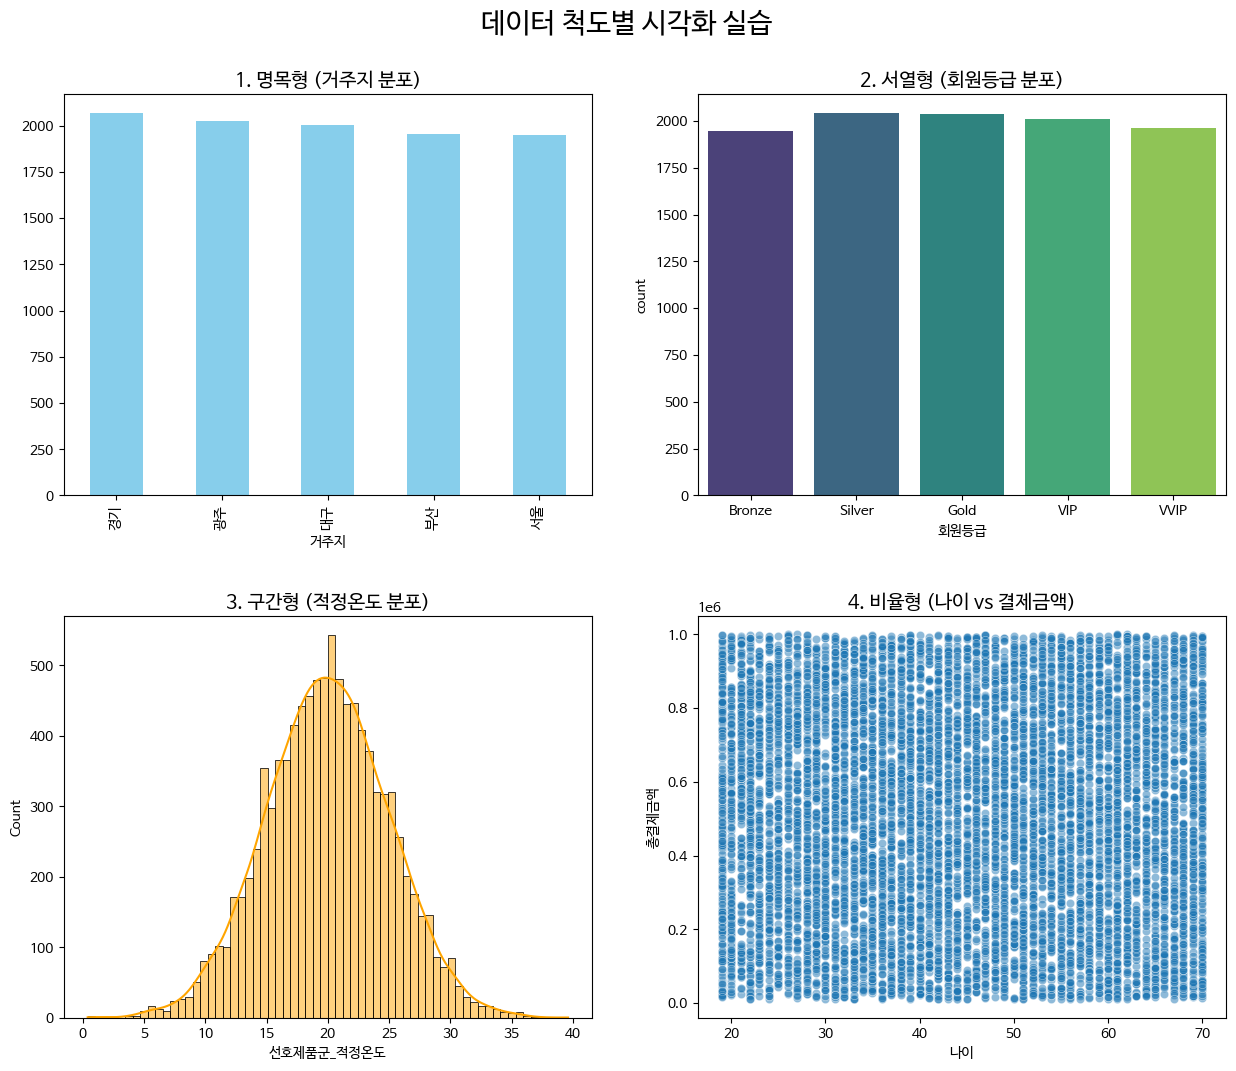

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 및 스타일 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 전체 도화지 크기 설정 (2행 2열)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.2) # 그래프 사이 간격 조절

# --- [1] 명목형 (Top-Left) ---
df['거주지'].value_counts().plot(kind='bar', color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title('1. 명목형 (거주지 분포)', fontsize=14)

# --- [2] 서열형 (Top-Right) ---
grade_order = ['Bronze', 'Silver', 'Gold', 'VIP', 'VVIP']
sns.countplot(x='회원등급', data=df, order=grade_order, palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title('2. 서열형 (회원등급 분포)', fontsize=14)

# --- [3] 구간형 (Bottom-Left) ---
sns.histplot(df['선호제품군_적정온도'], kde=True, color='orange', ax=axes[1, 0])
axes[1, 0].set_title('3. 구간형 (적정온도 분포)', fontsize=14)

# --- [4] 비율형 (Bottom-Right) ---
sns.scatterplot(x='나이', y='총결제금액', data=df, alpha=0.5, ax=axes[1, 1])
axes[1, 1].set_title('4. 비율형 (나이 vs 결제금액)', fontsize=14)

# 3. 전체 제목 설정 및 출력
plt.suptitle('데이터 척도별 시각화 실습', fontsize=20, y=0.95)
plt.show()